In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

In [ ]:
month_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
df = []
for mh in month_list:
    df_new = pd.read_csv("../data/ISONE_data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(40, 6))
sns.heatmap(hm_load, annot=True, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_spring_24.svg', format='svg')

FileNotFoundError: [Errno 2] No such file or directory: '../data/nodalloadweights_4006_202401.csv'

In [7]:
df.to_csv('Nantucket_2024.csv', index = False)

In [2]:
df = pd.read_csv('../data/Nantucket_2024.csv')

Text(0.5, 0, 'Days with load exceeding')

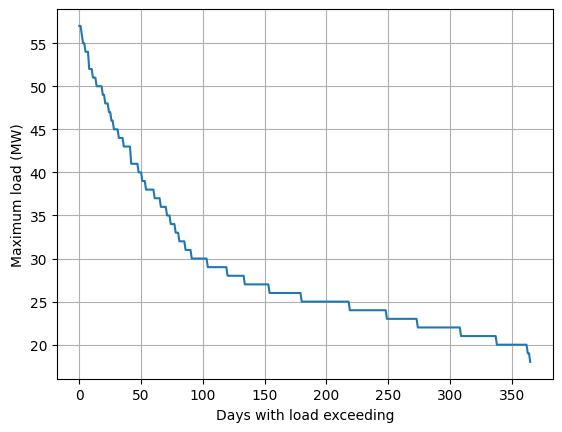

In [20]:
plt.plot(df.groupby('Day')["MW Factor"].max().sort_values(ascending = False).values)
plt.grid()
plt.ylabel('Maximum load (MW)')
plt.xlabel('Days with load exceeding')

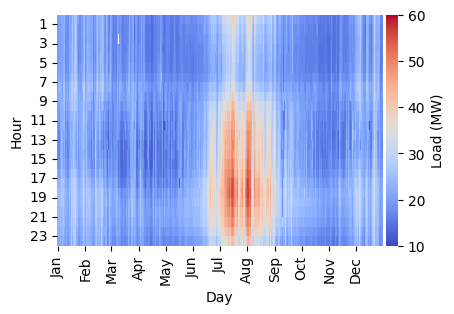

In [6]:
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_load, annot=False, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('load_24.pdf', format='pdf', bbox_inches = 'tight')

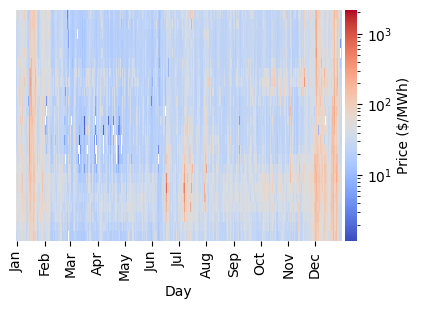

In [61]:
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, norm = LogNorm(), yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmin = 0.001)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('price_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('price_24.pdf', format='pdf', bbox_inches = 'tight')

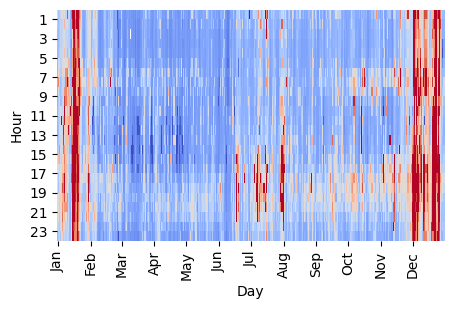

In [70]:
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': '', "pad": 0.01}, vmin = 0, vmax = 100, cbar = False)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('price_24_hours.svg', format='svg', bbox_inches = 'tight')
plt.savefig('price_24_hours.pdf', format='pdf', bbox_inches = 'tight')

Cambium data for 131 MA (https://scenarioviewer.nrel.gov/?project=0f92fe57-3365-428a-8fe8-0afc326b3b43&mode=download&layout=Default)

In [72]:
cb25 = pd.read_csv("../data/Cambium23_MidCase_hourly_p131_2025.csv", skiprows=5)
cb50 = pd.read_csv("../data/Cambium23_MidCase_hourly_p131_2050.csv", skiprows=5)
dt = pd.to_datetime(cb25.timestamp)
p25 = cb25.energy_cost_busbar
p50 = cb50.energy_cost_busbar
cb = pd.DataFrame({"dt": dt, "hour": dt.dt.hour, "day_of_year": dt.dt.dayofyear, "p25": p25, "p50": p50})

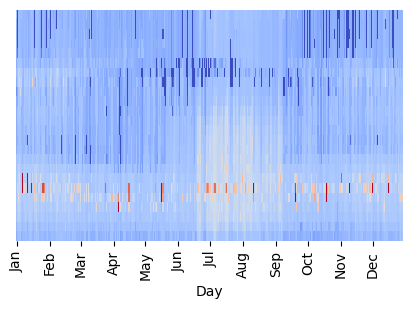

In [73]:
hm_price = cb.pivot(index = "hour", columns = "day_of_year", values = "p25")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmin = 0, vmax = 100, cbar = False)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('cambium_25.svg', format='svg', bbox_inches = 'tight')
plt.savefig('cambium_25.pdf', format='pdf', bbox_inches = 'tight')

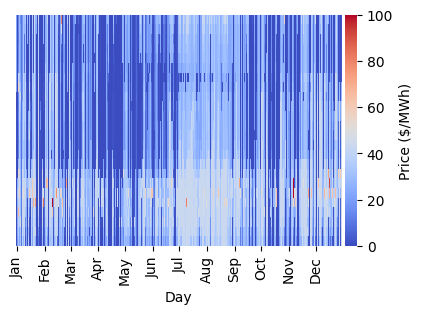

In [76]:
hm_price = cb.pivot(index = "hour", columns = "day_of_year", values = "p50")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmax = 100)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('cambium_50.svg', format='svg', bbox_inches = 'tight')
plt.savefig('cambium_50.pdf', format='pdf', bbox_inches = 'tight')

In [10]:
for i in df["Price"].sort_values():
    print(i)

-51.74
-30.91
-25.03
-24.2
-23.18
-18.72
-16.52
-15.84
-14.38
-13.88
-13.69
-13.53
-11.27
-11.03
-9.87
-9.3
-9.23
-9.02
-8.35
-8.21
-7.91
-5.87
-5.51
-3.22
-3.2
-3.18
-1.99
-1.82
-1.1
1.18
1.41
1.78
1.79
1.94
2.2
2.5
2.85
3.16
3.21
3.21
3.37
3.44
3.68
3.88
3.93
4.29
4.32
4.61
4.62
4.91
4.93
4.96
5.01
5.14
5.28
5.3
5.5
5.63
5.8
6.0
6.33
6.4
6.59
6.68
7.25
7.46
7.92
8.09
8.11
8.32
8.35
8.38
8.51
8.54
8.61
8.69
8.92
8.95
9.13
9.23
9.26
9.32
9.45
9.52
9.62
9.85
10.12
10.2
10.28
10.36
10.42
10.51
10.6
10.77
10.83
11.17
11.3
11.44
11.55
11.69
11.79
11.8
11.82
11.92
11.98
12.05
12.06
12.06
12.08
12.15
12.3
12.36
12.41
12.42
12.45
12.48
12.68
12.73
12.82
12.91
12.94
12.99
12.99
12.99
13.04
13.11
13.13
13.15
13.16
13.19
13.35
13.37
13.45
13.47
13.53
13.59
13.6
13.7
13.77
13.8
13.91
13.98
14.0
14.02
14.03
14.04
14.19
14.22
14.24
14.25
14.25
14.28
14.3
14.3
14.35
14.37
14.4
14.43
14.46
14.49
14.53
14.6
14.6
14.61
14.65
14.67
14.67
14.68
14.73
14.76
14.76
14.78
14.81
14.84
14.85
14.85
14.86
14.88


In [5]:
df[df["Day"] == "2024-08-01"]

,H,Day,Hour,Location ID,Network Node Description,MW Factor,Energy Component,Congestion Component,Marginal Loss Component,Price
5111,D,2024-08-01,1,16255.0,LD.CANDLE 13.2,34.0,53.39,0.09,0.67,54.15
5112,D,2024-08-01,2,16255.0,LD.CANDLE 13.2,32.0,33.11,0.00,0.39,33.50
5113,D,2024-08-01,3,16255.0,LD.CANDLE 13.2,31.0,31.10,0.00,0.36,31.46
5114,D,2024-08-01,4,16255.0,LD.CANDLE 13.2,30.0,31.43,0.00,0.37,31.80
5115,D,2024-08-01,5,16255.0,LD.CANDLE 13.2,30.0,34.54,0.00,0.40,34.94
5116,D,2024-08-01,6,16255.0,LD.CANDLE 13.2,29.0,30.54,0.00,0.34,30.88
5117,D,2024-08-01,7,16255.0,LD.CANDLE 13.2,31.0,41.37,0.00,0.54,41.91
5118,D,2024-08-01,8,16255.0,LD.CANDLE 13.2,35.0,52.60,0.00,0.73,53.33
5119,D,2024-08-01,9,16255.0,LD.CANDLE 13.2,37.0,44.00,0.00,0.61,44.61
5120,D,2024-08-01,10,16255.0,LD.CANDLE 13.2,41.0,48.27,0.00,0.56,48.83


In [4]:
for i in df[df["Day"] == "2024-06-18"]["MW Factor"]:
    print(i)

21.0
20.0
19.0
19.0
19.0
18.0
19.0
22.0
23.0
26.0
26.0
25.0
26.0
27.0
27.0
28.0
29.0
32.0
33.0
33.0
32.0
31.0
29.0
25.0


In [8]:
df["Price"].max()

np.float64(2173.15)

In [11]:
df["MW Factor"].max()

np.float64(57.0)